# Example of Making a PSF

The point-spread function (PSF) is an essential component for modeling of strongly lensed quasars, describing how the point-like quasar images are defracted by a detector. In this notebook, we provide an example of creating a PSF from stars in a science mosaic using the two methodologies currently implemented in Dolphin:
1) PSFr ([GitHub](https://github.com/sibirrer/psfr))
2) STARRED ([GitLab](https://gitlab.com/cosmograil/starred))

# Initializing the PSF class

In order to initialize the PSF class, the full science image must be present in the ``io_directory/data/lens_system`` directory as ``full_image_{lens_system}_{data_band}.fits``. For HST data, an additional file containing the weight information must also be in the directory as ``weight_image_{lens_name}_{data_band}.fits``.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

from dolphin.preprocessing.psf import PSF

io_directory = "../io_directory_example"
lens_name = "lensed_quasar_3"
data_band = "F814W"

psf = PSF(
    io_directory=io_directory,
    lens_name=lens_name,
    data_band=data_band,
    instrument="HST",
)

# Get the cutting dictionary and Source Extractor catalog

To obtain a catalog of all sources in the science image, Source Extractor is run. In order for SExtractor to properly perform, there are four files that need to be in your working directory:

1) ``default.sex``
2) ``default.param``
3) ``default.conv``
4) ``default.nnw``

Examples of these four files can be found at the [Source Extractor GitHub](https://github.com/astromatic/sextractor).

We also need to obtain a dictionary that contains the criterion over which we want to identify candidate stars (i.e. sources in the image over a magnitude range, size range, etc.). ``psf.get_kwargs_cut`` gives us both this dictionary and the SExtractor catalog. The SExtractor catalog is also automatically saved to ``io_directory/data/{lens_system}/preprocessing/{data_band}`` and can be reloaded with ``psf.get_catalog_table`` to make a future PSF from that catalog without having to rerun SExtractor.

In [2]:
kwargs_cut, catalog = psf.get_kwargs_cut()

> 
----- SExtractor 2.28.0 started on 2026-07-10 at 16:25:45 with 1 thread

> Setting catalog parameters
> Reading detection filter
> Initializing Neural Network
> Reading Neural Network Weights
> Initializing catalog
> Looking for full_image_lensed_quasar_3_F814W.fits
----- Measuring from: full_image_lensed_quasar_3_F814W.fits [0/2]
      "Unnamed" / no ext. header / 5793x5869 / 32 bits (floats)
Detection+Measurement image: > Setting up background maps
> Setting up background map at line:   64
> Setting up background map at line:  128
> Setting up background map at line:  192
> Setting up background map at line:  256
> Setting up background map at line:  320
> Setting up background map at line:  384
> Setting up background map at line:  448
> Setting up background map at line:  512
> Setting up background map at line:  576
> Setting up background map at line:  640
> Setting up background map at line:  704
> Setting up background map at line:  768
> Setting up background map at line:  

# Generate star cutouts, cutout weights, and noise maps

The generated cutting dictionary should be modified to the bounds that best suit the stars in our science image. After this, we can propagate the cutting dictionary and catalog information into ``psf.get_psf_candidates``, which generates cutouts of the stars that match our criterion, their weight maps, and their noise maps. This function also automatically masks out objects that are flagged by SExtractor (i.e. for being blended, saturated, etc.), as well as objects within a 100 pixel radius of the target object (this is so that the quasar images are not picked as candidate stars). Either of these options can be toggled with ``exclude_flags`` and ``radius_pix``.

This first time, we will run it with ``save=False`` to visually inspect the candidate stars and identify those that should be removed.

Objects with non-zero flags excluded.
Objects along image boundary excluded.
Found 7 candidate objects!


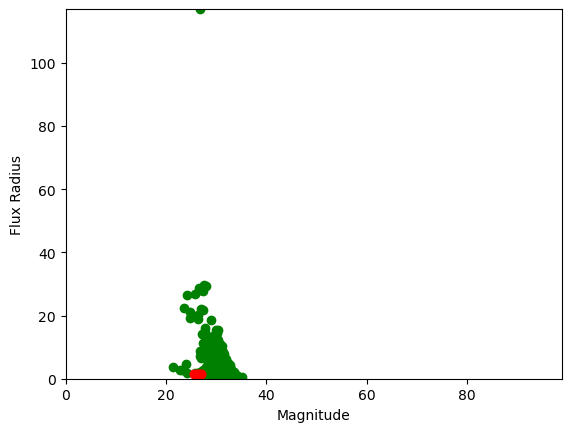

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:695: RuntimeWarning: invalid value encountered in log10
  ax[i].imshow(np.log10(star_exposures[i]), cmap="viridis")


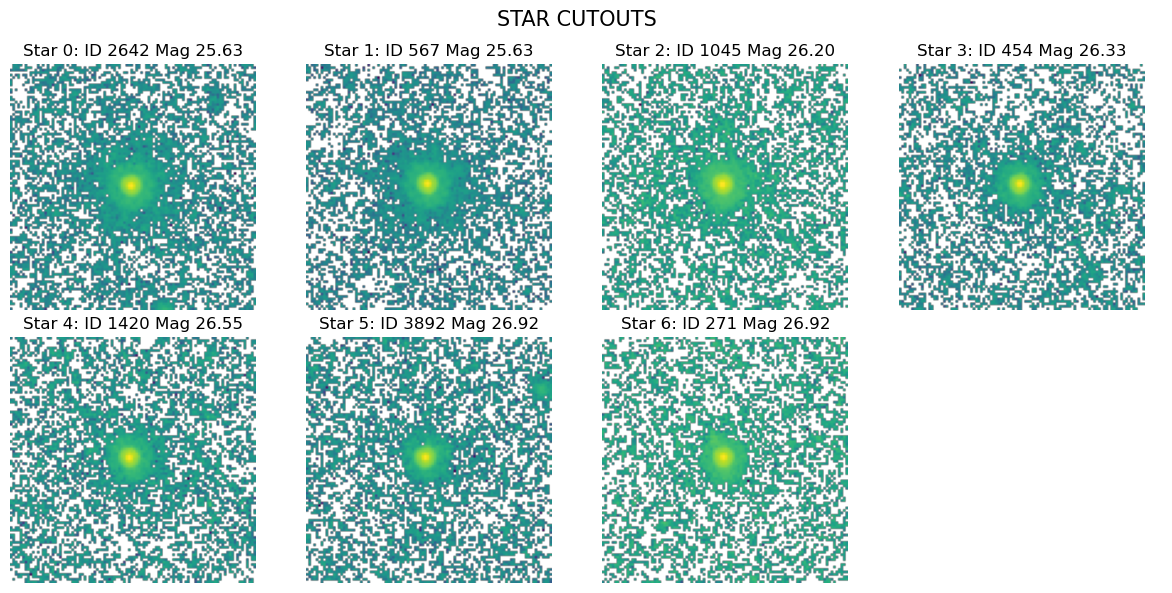

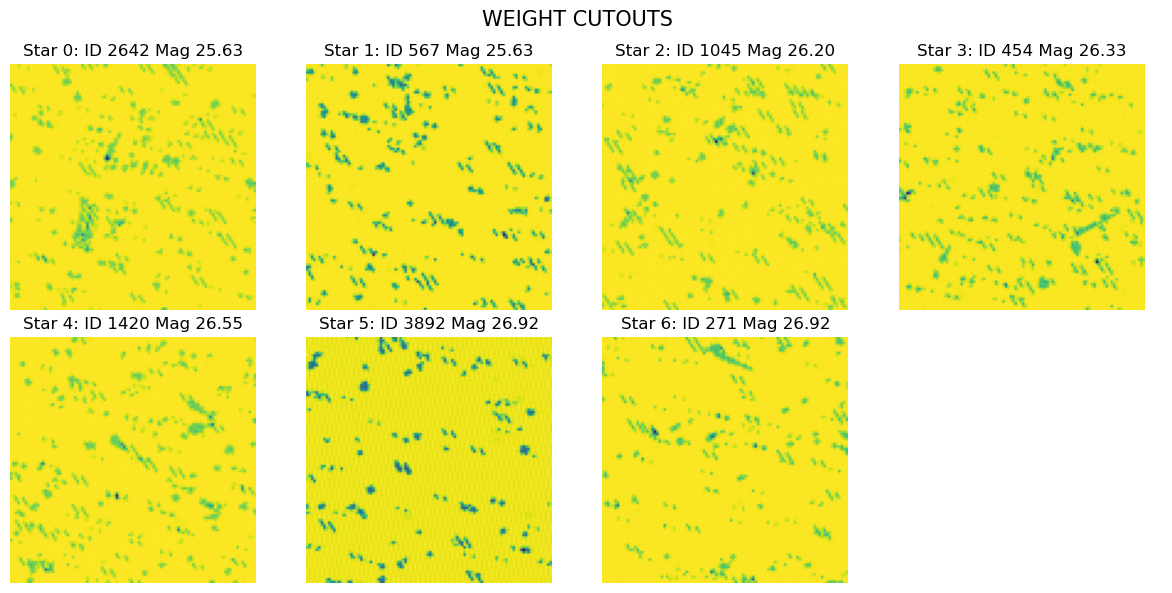

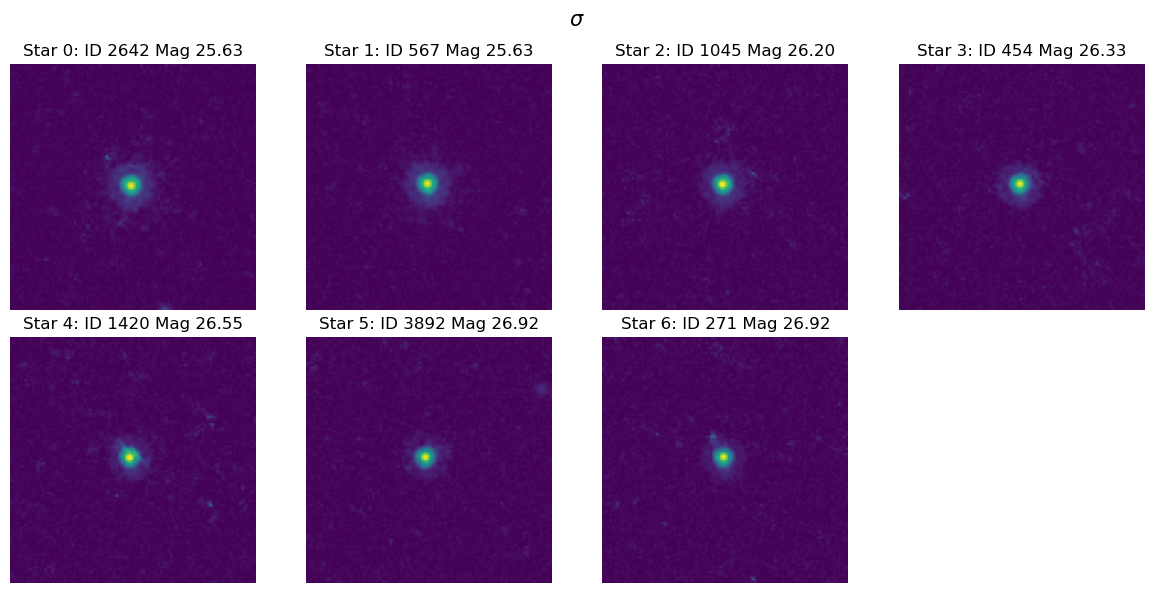

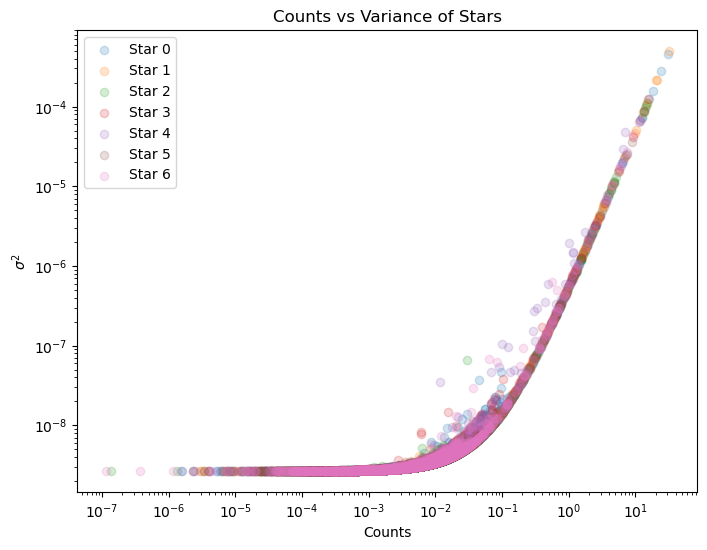

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:791: RuntimeWarning: invalid value encountered in log10
  plt_data = np.log10(data_full + 0.1)


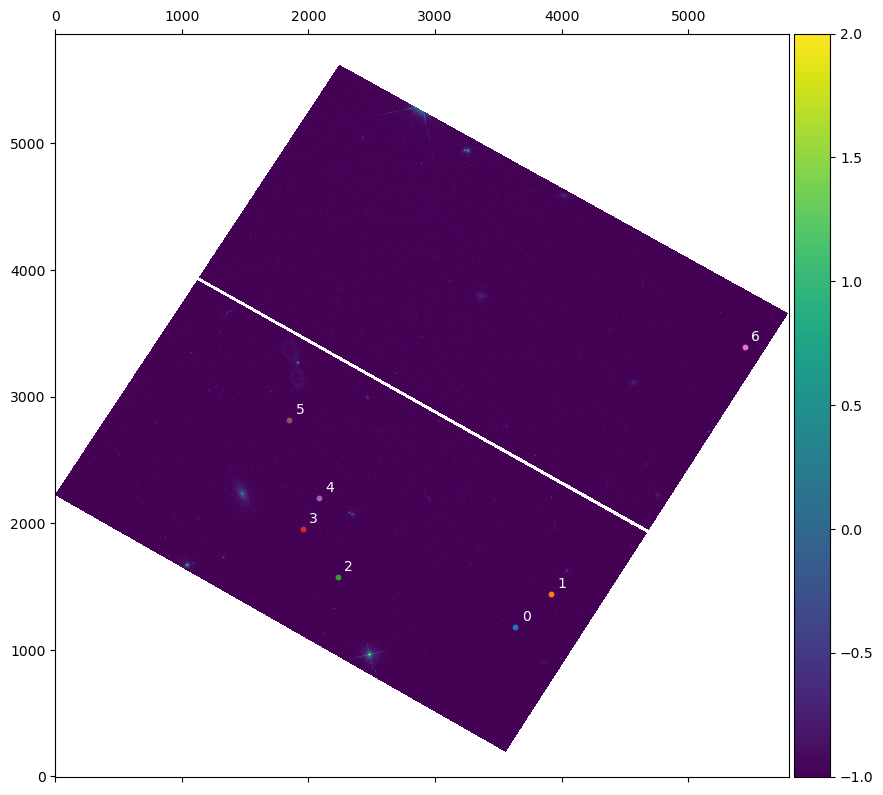

In [3]:
kwargs_cut["EllipticityThresh"] = 0.2
kwargs_cut["SizeMinThresh"] = 1.0
kwargs_cut["SizeMaxThresh"] = 4.3
kwargs_cut["MagMaxThresh"] = 27
kwargs_cut["MagMinThresh"] = 22
kwargs_cut["ClassStarMin"] = 0.1

star_exposures, star_weights, noise_maps = psf.get_psf_candidates(
    catalog=catalog, kwargs_cut=kwargs_cut, save=False
)

For the purposes of this example, we will remove Star 6 since it is the lowest magnitude star. We can exclude that object from our candidates by toggling the ``exclude_specific`` option, which takes a list of the catalog ID numbers of objects which we do not want to propagate to the PSF fitting.

Another diagnostic to investigate is the Variance vs. Counts of our candidate stars. For pixels dominated by background noise, the variance should approach a roughly constant floor at low count levels, corresponding to the read noise, sky background, and other additive noise sources. As the counts increase and Poisson statistics begin to dominate, the variance should scale linearly with the signal.

Objects with non-zero flags excluded.
Objects along image boundary excluded.
Excluded 1 specified objects.
Found 6 candidate objects!


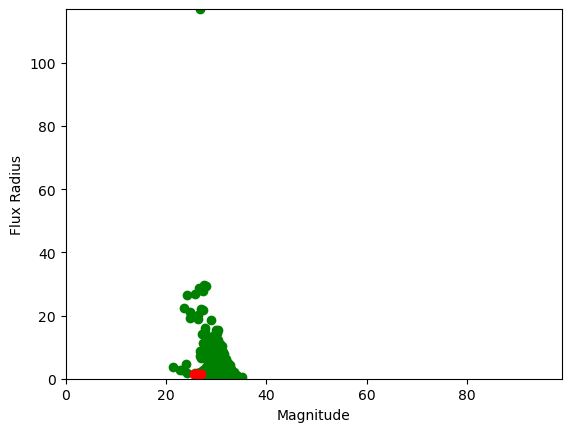

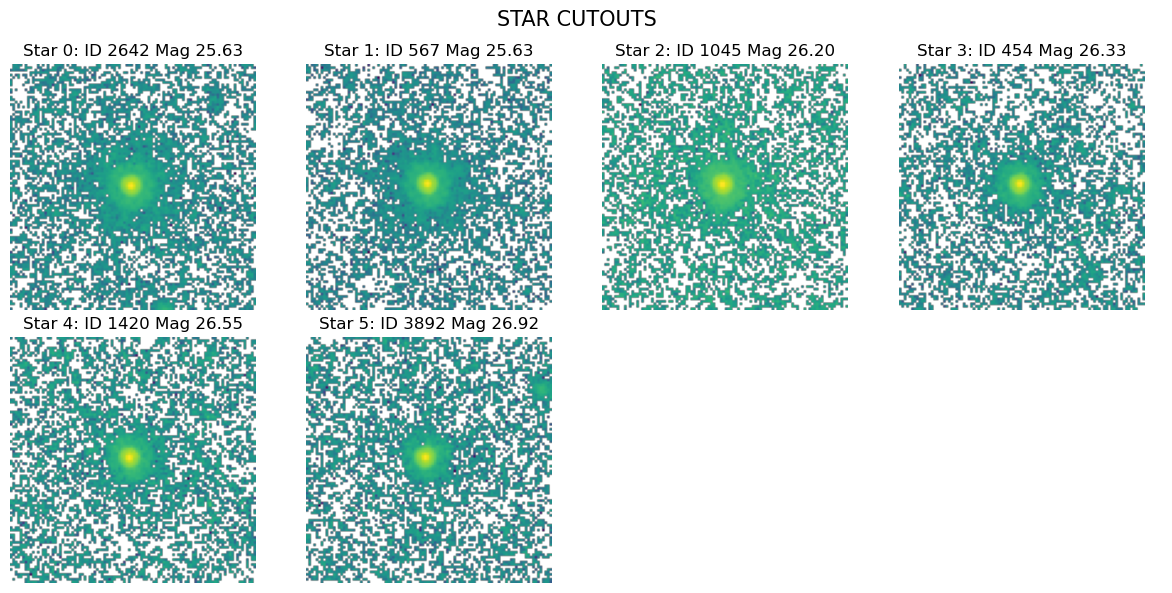

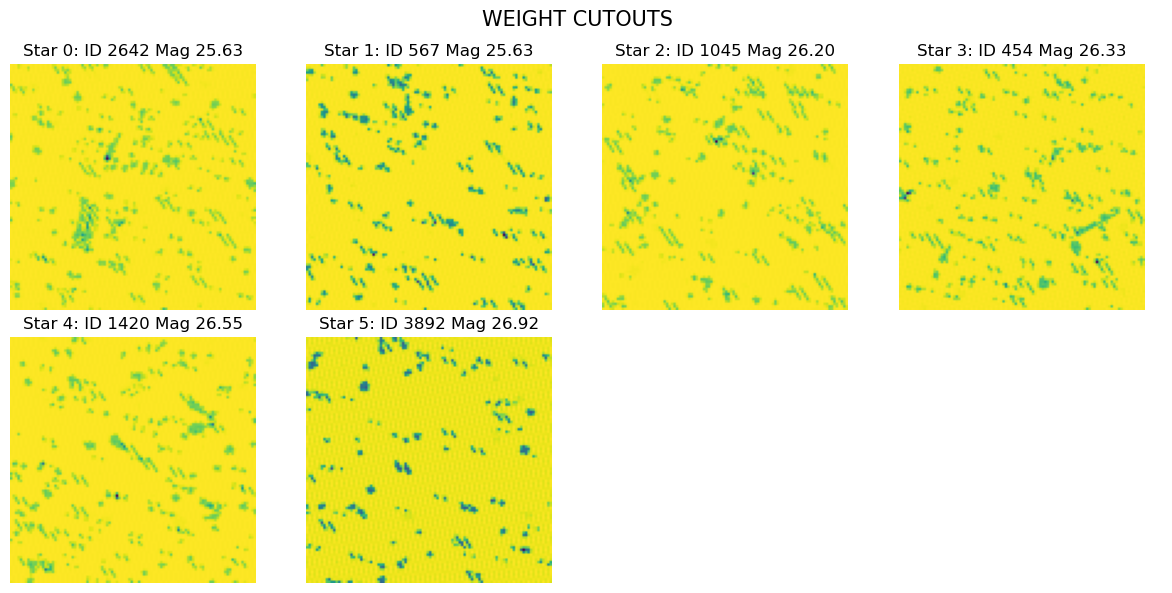

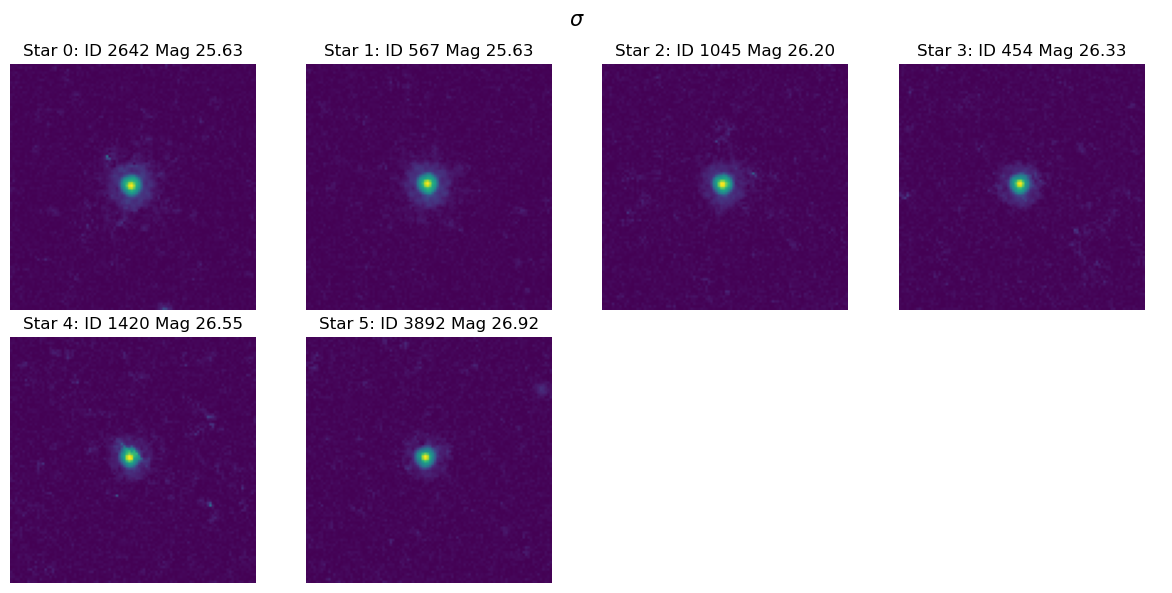

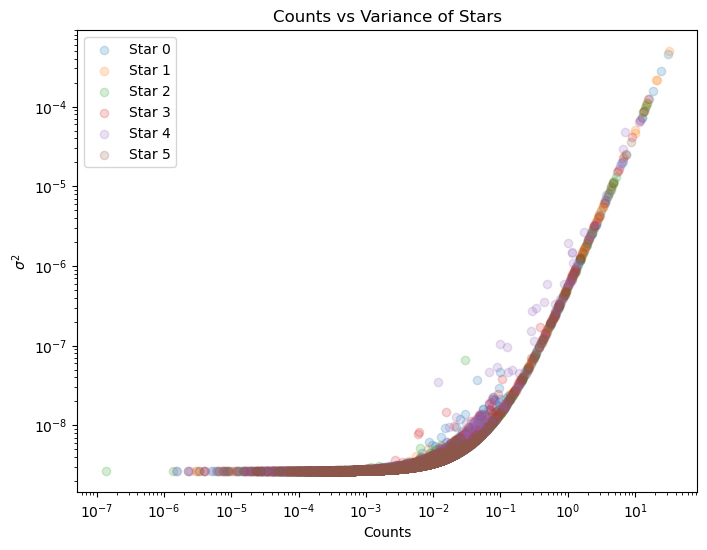

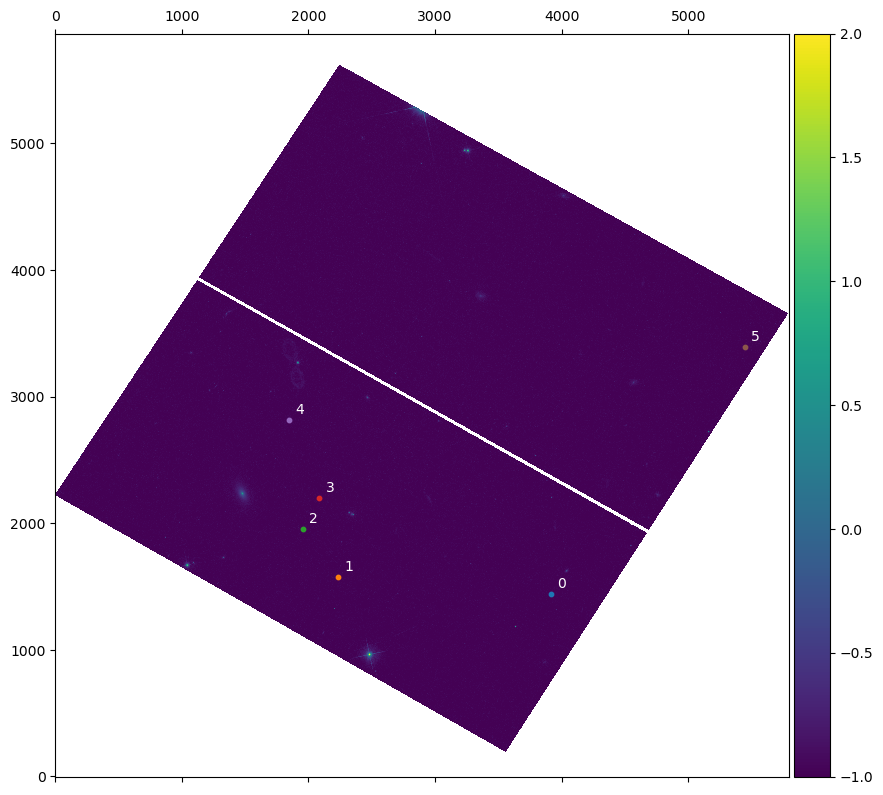

In [4]:
star_exposures, star_weights, noise_maps = psf.get_psf_candidates(
    catalog=catalog, kwargs_cut=kwargs_cut, exclude_specific=[271], save=True
)

# Masking Regions

If we want to mask out any regions of the image, we must save the masked region as a ``.npy`` file in the ``preprocessing/{data_band}/masks`` directiory as ``mask_{i}.npy``, where ``i`` corresponds to the number of the star over which this mask applies. The `PSF` class also contains a helper function to make masks around specified regions of specified candidate stars. The three different mask options are `circle`, `square`, and `ellipse`. The masks can be stacked in an array of dictionaries to remove an arbitrary collection of regions from a candidate image. To invert the boolean logic of a specific mask components (for example, to change the logic from being `True` inside a region to `False` inside that same region), the key `"invert": True` must be present in that dictionary. For this example, we will apply a circular mask around the boundary of Star 5, and it will be saved in the expected `PSF` format.

No mask found for star 0, using default (all True).
No mask found for star 1, using default (all True).
No mask found for star 2, using default (all True).
No mask found for star 3, using default (all True).
No mask found for star 4, using default (all True).
Using mask /Users/rbrady0110/gits/dolphin/io_directory_example/data/lensed_quasar_3/preprocessing/F814W/masks/mask_5.npy for star 5!


/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:320: RuntimeWarning: divide by zero encountered in log10
  ax[0].imshow(np.log10(star_exposure * mask))
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:320: RuntimeWarning: invalid value encountered in log10
  ax[0].imshow(np.log10(star_exposure * mask))
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:322: RuntimeWarning: divide by zero encountered in log10
  ax[1].imshow(np.log10(weight_map * mask))
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:324: RuntimeWarning: divide by zero encountered in log10
  ax[2].imshow(np.log10(noise_map * mask))


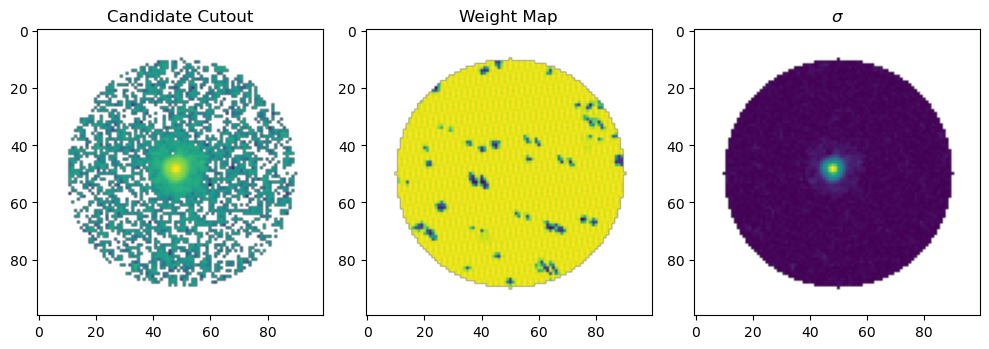

In [5]:
kwargs_mask = [{"type": "circle", "center": (50, 50), "radius": 40, "invert": False}]

psf.make_candidate_mask(
    star_num=5,
    kwargs_mask=kwargs_mask,
    save=True,
)

# 1) Making a PSF with PSFr

We can make a PSF using the PSFr software easily with ``psf.make_psf_psfr``. Many of the inputs correspond to those asked by PSFr (see their documentation for further information). Exclusively here, there is an option to cut pixels that are below a certain threshold from the final PSF with `cut_threshold`, which is mainly used to exclude low-signal pixels at the outer edges of the PSF. Once we have determined a PSF that looks reasonable, ``save=True`` saves the PSF in an HDF5 file format which is expected by Dolphin and is automatically put in the proper data directory.

No mask found for star 0, using default (all True).
No mask found for star 1, using default (all True).
No mask found for star 2, using default (all True).
No mask found for star 3, using default (all True).
No mask found for star 4, using default (all True).
Using mask /Users/rbrady0110/gits/dolphin/io_directory_example/data/lensed_quasar_3/preprocessing/F814W/masks/mask_5.npy for star 5!


/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:960: RuntimeWarning: invalid value encountered in log10
  im_psf = ax[0].imshow(np.log10(psf_guess), origin="lower", cmap="viridis")
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:964: RuntimeWarning: divide by zero encountered in log10
  im_variance = ax[1].imshow(np.log10(variance_map), origin="lower")


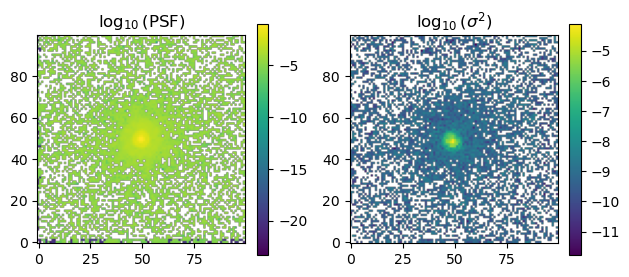

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:973: RuntimeWarning: divide by zero encountered in log10
  ax[0].imshow(np.log10(psf_cut))
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:977: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 4 Axes> than <Figure size 640x480 with 3 Axes> which fig.colorbar is called on.
  fig.colorbar(im_psf, ax=ax[0], fraction=0.05)
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:979: RuntimeWarning: divide by zero encountered in log10
  ax[1].imshow(np.log10(variance_map_cut))
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:982: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 4 Axes> than <Figure size 640x480 with 4 Axes> which fig.colorbar is called on.
  fig.colorbar(im_variance, ax=ax[1], fraction=0.05)


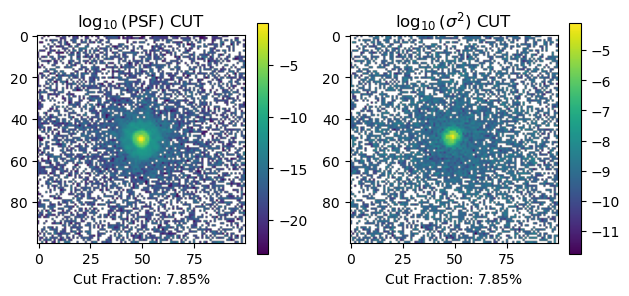

In [6]:
psf_psfr, error_map_psfr = psf.make_psf_psfr(cut_threshold=1.0e-6, save=True)

# 2) Making a PSF with STARRED

Similarly to PSFr, many of the inputs for the STARRED branch of making a PSF are parameters that can be read about in the STARRED documentation. The two unique Dolphin parameters are again ``cut_threshold`` and ``save``.

No mask found for star 0, using default (all True).
No mask found for star 1, using default (all True).
No mask found for star 2, using default (all True).
No mask found for star 3, using default (all True).
No mask found for star 4, using default (all True).
Using mask /Users/rbrady0110/gits/dolphin/io_directory_example/data/lensed_quasar_3/preprocessing/F814W/masks/mask_5.npy for star 5!


/Users/rbrady0110/micromamba/envs/dolphin/lib/python3.14/site-packages/starred/optim/optimization.py:181: UserWarning: You are using an unconstrained optimiser. Bounds are ignored.
  warnings.warn('You are using an unconstrained optimiser. Bounds are ignored.')
/Users/rbrady0110/micromamba/envs/dolphin/lib/python3.14/site-packages/starred/utils/noise_utils.py:53: RuntimeWarning: Mean of empty slice
  noise_map = np.nanmean(centered_masked_noise_maps, axis=0)
optax.adabelief: 100%|██████████| 1500/1500 [00:02<00:00, 549.00it/s]


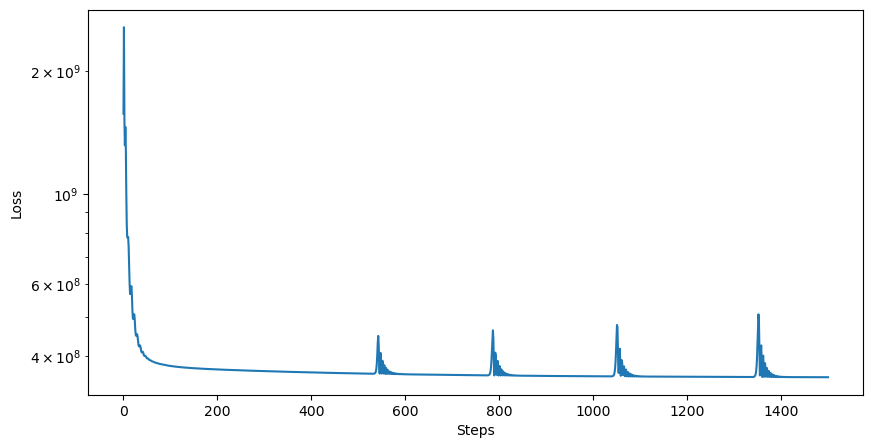

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:992: RuntimeWarning: invalid value encountered in log10
  im_psf = ax[0].imshow(np.log10(psf_guess), origin="lower", cmap="viridis")


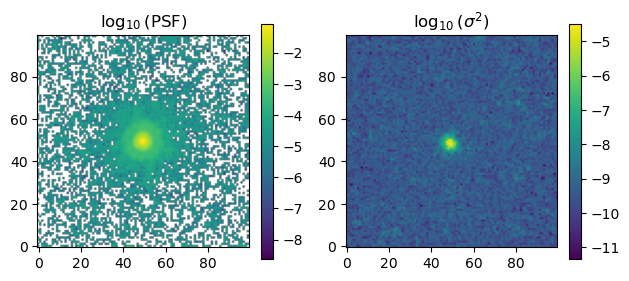

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:1005: RuntimeWarning: divide by zero encountered in log10
  ax[0].imshow(np.log10(psf_cut))
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:1011: RuntimeWarning: divide by zero encountered in log10
  ax[1].imshow(np.log10(variance_map_cut))


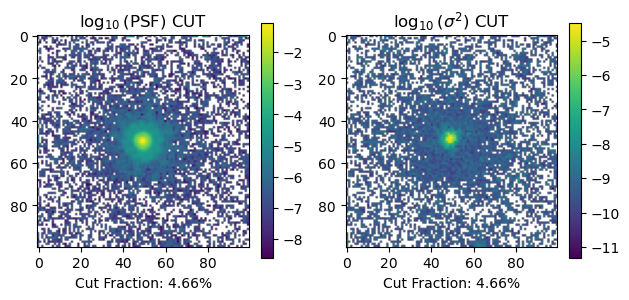

In [8]:
psf_starred, error_map_starred = psf.make_psf_starred(cut_threshold=1.0e-6, save=False)

Congratulations! You have just made a PSF using both the PSFr and STARRED software. Let's see how they compare:

Text(0.5, 1.0, 'PSFr - STARRED / max($\\text{PSF}_\\text{PSFr}$)')

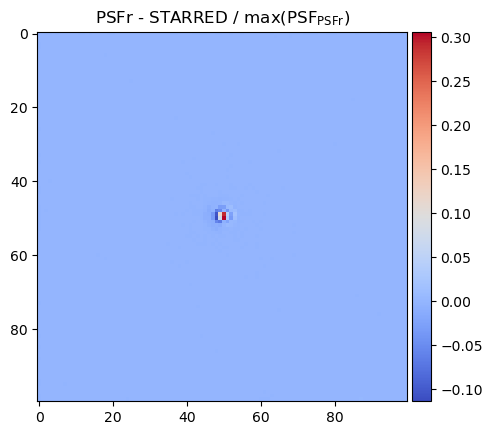

In [9]:
fig, ax = plt.subplots(1)
im1 = ax.imshow((psf_psfr - psf_starred) / np.max(psf_psfr), cmap="coolwarm")
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax, orientation="vertical")
ax.set_title(r"PSFr - STARRED / max($\text{PSF}_\text{PSFr}$)")

# Some helper functions

If we ever wanted to make another PSF out of the SExtractor catalog, but do not want to wait for a new catalog to be made, we can get the catalog and initialize the cutting dictionary like so:

In [9]:
catalog = psf.load_catalog_table()

mag = np.array(catalog.data["MAG_BEST"], dtype=float)
size = np.array(catalog.data["FLUX_RADIUS"], dtype=float)

kwargs_cut = {}
mag_max = min(np.max(mag), 34)
mag_min = np.min(mag)
delta_mag = mag_max - mag_min
kwargs_cut["MagMaxThresh"] = mag_max - 0.7 * delta_mag
kwargs_cut["MagMinThresh"] = mag_min  # + 0.01*delta_mag

mask = mag < mag_max - 0.5 * delta_mag
kwargs_cut["SizeMinThresh"] = max(0, np.min(size[mask]))
kwargs_cut["SizeMaxThresh"] = max(0, np.min(size[mask]) + 4)
kwargs_cut["EllipticityThresh"] = 0.1
kwargs_cut["ClassStarMax"] = 1.0
kwargs_cut["ClassStarMin"] = 0.5

We can also easily plot the final saved PSF and error map:

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:1034: RuntimeWarning: divide by zero encountered in log10
  im_psf = ax[0].imshow(np.log10(psf_data), origin="lower", cmap="viridis")
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:1038: RuntimeWarning: divide by zero encountered in log10
  im_variance = ax[1].imshow(np.log10(variance_map), origin="lower")


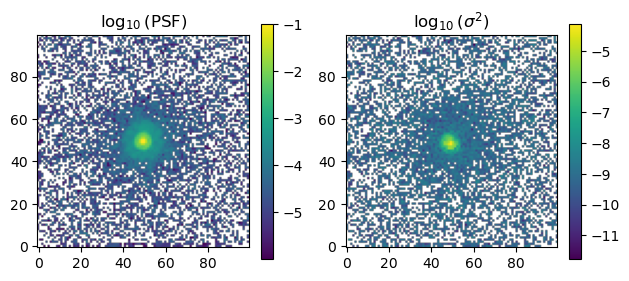

In [7]:
psf_saved, variance_map_saved = psf.load_saved_psf(plot=True)

If we ever wanted to retrieve the raw arrays containing the image cutouts, masks, weight cutouts, and noise maps, we can run the following:

In [10]:
star_data_list, mask_data_list, weight_maps, noise_maps = (
    psf.load_psf_candidate_attributes()
)

No mask found for star 0, using default (all True).
No mask found for star 1, using default (all True).
No mask found for star 2, using default (all True).
No mask found for star 3, using default (all True).
No mask found for star 4, using default (all True).
Using mask /Users/rbrady0110/gits/dolphin/io_directory_example/data/lensed_quasar_3/preprocessing/F814W/masks/mask_5.npy for star 5!


If we ever wanted to plot the saved candidates, we could quickly do so:

No mask found for star 0, using default (all True).
No mask found for star 1, using default (all True).
No mask found for star 2, using default (all True).
No mask found for star 3, using default (all True).
No mask found for star 4, using default (all True).
Using mask /Users/rbrady0110/gits/dolphin/io_directory_example/data/lensed_quasar_3/preprocessing/F814W/masks/mask_5.npy for star 5!


/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:827: RuntimeWarning: invalid value encountered in log10
  image = np.log10(star_exposures[i])


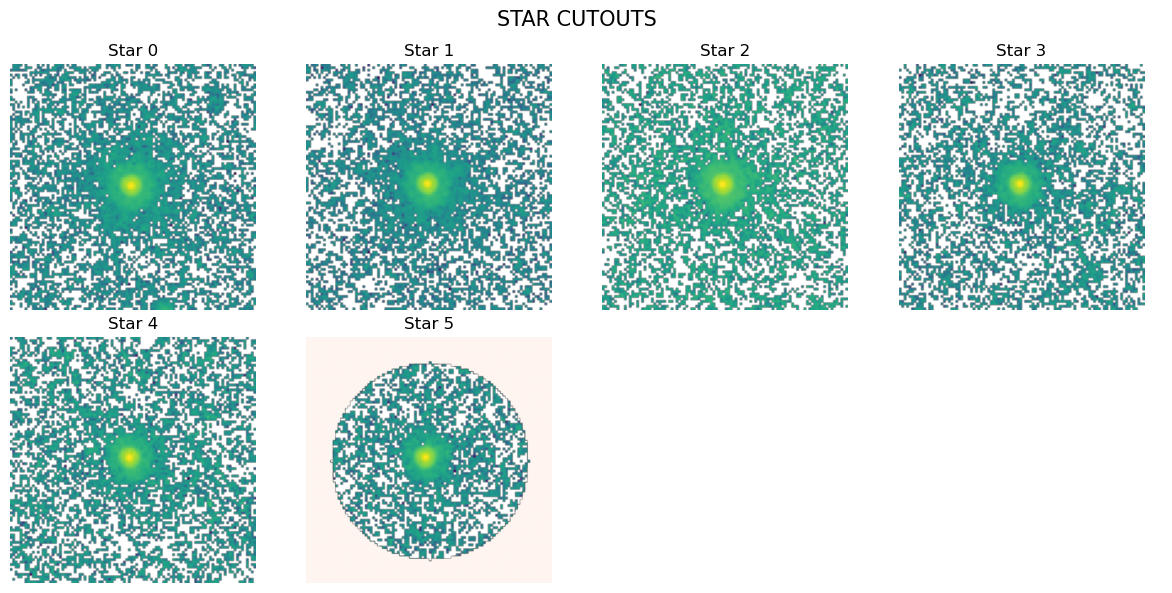

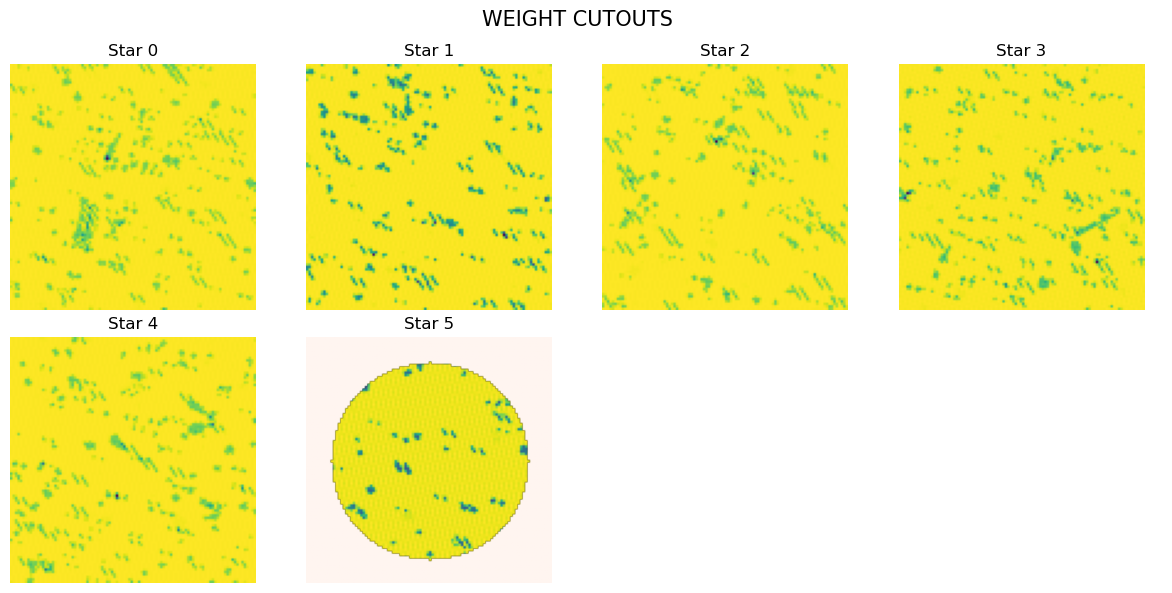

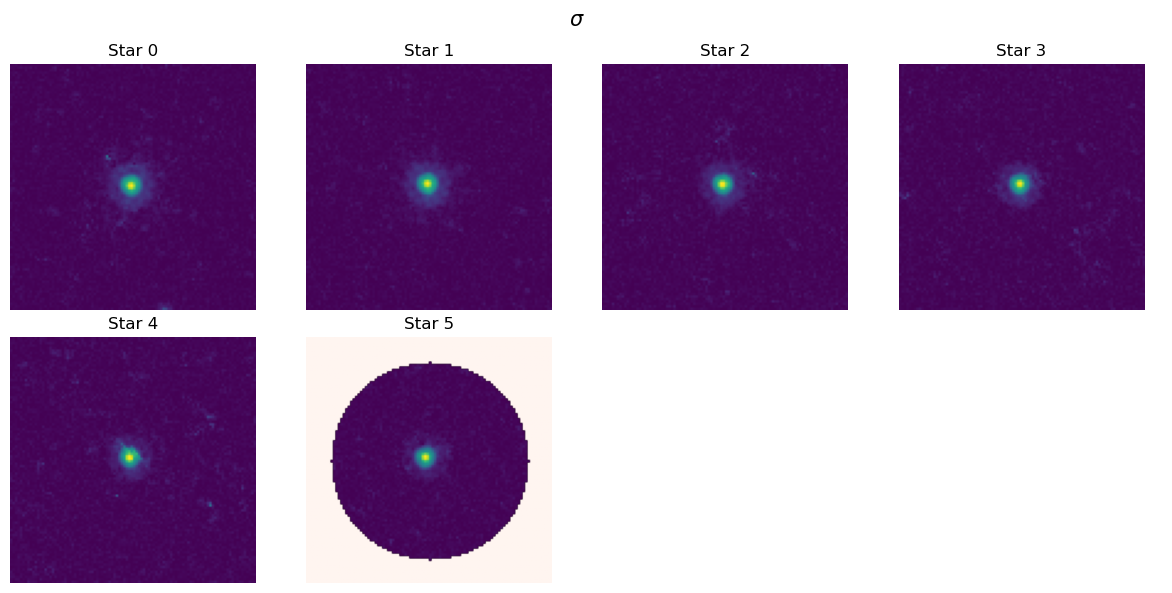

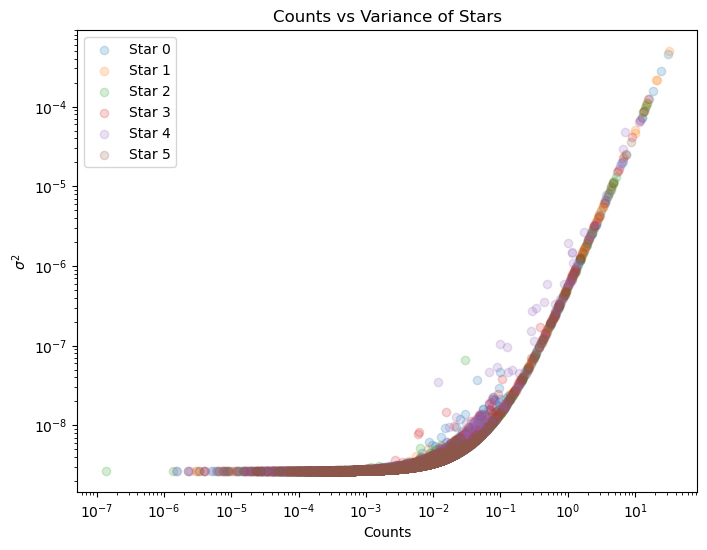

In [11]:
psf.plot_saved_psf_candidates()